# SUS001 Energy Consumption Analysis

This notebook implements the pre-registered statistical analysis procedure for evaluating whether applying `SUS001` leads to statistically significant and meaningful changes in energy consumption across repositories.

**Stages:**
1. Data loading & EDA
2. Per-repository analysis (Shapiro-Wilk -> parametric or non-parametric)
3. Linear mixed-effects model across all repositories

---
## Stage 0 -- Data Loading & Exploratory Data Analysis

### 0.1 Imports

In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

### 0.2 Configuration

In [2]:
# ── USER CONFIG ─────────────────────────────────────────────────────────────
DATA_DIR        = "results/run_2026-03-29_17-00-04/"          # folder containing the CSV files
CSV_GLOB        = "*/*.csv"          # pattern to match your CSV files

BASELINE_LABEL  = "baseline"       # value in the `condition` column for baseline
TREATMENT_LABEL = "treatment"      # value in the `condition` column for treatment

ENERGY_COL      = "total_energy_j" # column with energy measurements
CONDITION_COL   = "condition"
REPO_COL        = "repo"
RUN_INDEX_COL   = "run_index"      # used to pair baseline ↔ treatment runs

RESULTS_DIR     = "analysis/run_2026-03-29_17-00-04/"
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
# ────────────────────────────────────────────────────────────────────────────

### 0.3 Load CSVs

In [3]:
csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, CSV_GLOB)))
print(f"Found {len(csv_paths)} CSV file(s):")
for p in csv_paths:
    print(f"  {p}")

raw_frames = [pd.read_csv(p) for p in csv_paths]
df_raw = pd.concat(raw_frames, ignore_index=True)

print(f"\nTotal rows loaded: {len(df_raw):,}")
df_raw.head(10)

Found 4 CSV file(s):
  results/run_2026-03-29_17-00-04/ArchiSteamFarm-SE/raw.csv
  results/run_2026-03-29_17-00-04/congo-SE/raw.csv
  results/run_2026-03-29_17-00-04/django-compressor-SE/raw.csv
  results/run_2026-03-29_17-00-04/rq-SE/raw.csv

Total rows loaded: 230


,repo,condition,run_index,run_id,dispatched_at,total_energy_j
0,ArchiSteamFarm-SE,baseline,1,23715351068,2026-03-29T17:55:36.823466+00:00,1.117968
1,ArchiSteamFarm-SE,treatment,1,23715423132,2026-03-29T17:59:25.479182+00:00,0.338111
2,ArchiSteamFarm-SE,baseline,2,23715461506,2026-03-29T18:01:11.776335+00:00,1.164766
3,ArchiSteamFarm-SE,treatment,2,23715864424,2026-03-29T18:21:04.482034+00:00,0.390770
4,ArchiSteamFarm-SE,baseline,3,23715921322,2026-03-29T18:24:10.497651+00:00,1.142581
5,ArchiSteamFarm-SE,treatment,3,23715996685,2026-03-29T18:28:00.395316+00:00,0.336451
6,ArchiSteamFarm-SE,baseline,4,23716037686,2026-03-29T18:30:07.679398+00:00,1.148851
7,ArchiSteamFarm-SE,treatment,4,23716113713,2026-03-29T18:33:56.852685+00:00,0.349278
8,ArchiSteamFarm-SE,baseline,5,23716156078,2026-03-29T18:36:04.649010+00:00,1.143746
9,ArchiSteamFarm-SE,treatment,5,23716227913,2026-03-29T18:39:53.612832+00:00,0.321531


### 0.4 Basic Data Validation

In [4]:
required_cols = [REPO_COL, CONDITION_COL, RUN_INDEX_COL, ENERGY_COL]
missing_cols  = [c for c in required_cols if c not in df_raw.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"
print("All required columns present")

null_counts = df_raw[required_cols].isnull().sum()
print("\nNull counts per column:")
print(null_counts.to_string())

found_conditions = df_raw[CONDITION_COL].unique()
print(f"\nCondition values found: {found_conditions}")
for label in [BASELINE_LABEL, TREATMENT_LABEL]:
    assert label in found_conditions, f"Expected condition '{label}' not found!"
print("Both condition labels found")

All required columns present

Null counts per column:
repo              0
condition         0
run_index         0
total_energy_j    0

Condition values found: ['baseline' 'treatment']
Both condition labels found


In [5]:
run_counts = (
    df_raw.groupby([REPO_COL, CONDITION_COL])
    .size()
    .unstack(fill_value=0)
    .rename(columns={BASELINE_LABEL: "n_baseline", TREATMENT_LABEL: "n_treatment"})
)
run_counts["balanced"] = run_counts["n_baseline"] == run_counts["n_treatment"]
print(run_counts.to_string())

if not run_counts["balanced"].all():
    print("\nWARNING: some repos have unequal baseline/treatment counts.")

condition             n_baseline  n_treatment  balanced
repo                                                   
ArchiSteamFarm-SE             28           29     False
congo-SE                      28           27     False
django-compressor-SE          29           30     False
rq-SE                         29           30     False



### 0.5 Build the Paired Dataset

Pivot to wide format so that each row represents one matched pair `(baseline_energy, treatment_energy)` for a given `repo x run_index`. The paired difference `diff = treatment - baseline` is what the statistical tests operate on.

In [6]:
df_wide = (
    df_raw
    .pivot_table(
        index=[REPO_COL, RUN_INDEX_COL],
        columns=CONDITION_COL,
        values=ENERGY_COL
    )
    .rename(columns={BASELINE_LABEL: "energy_baseline", TREATMENT_LABEL: "energy_treatment"})
    .reset_index()
)

# Paired difference: positive = treatment uses MORE energy
df_wide["diff"] = df_wide["energy_treatment"] - df_wide["energy_baseline"]

# Drop unpaired rows (run_index present in only one condition)
n_before = len(df_wide)
df_wide  = df_wide.dropna(subset=["energy_baseline", "energy_treatment", "diff"])
n_after  = len(df_wide)
if n_before != n_after:
    print(f"Dropped {n_before - n_after} unpaired row(s) containing NaN.")

print(f"Paired rows: {len(df_wide)}")
df_wide.head(10)

Dropped 10 unpaired row(s) containing NaN.
Paired rows: 110


condition,repo,run_index,energy_baseline,energy_treatment,diff
0,ArchiSteamFarm-SE,1,1.117968,0.338111,-0.779857
1,ArchiSteamFarm-SE,2,1.164766,0.390770,-0.773996
2,ArchiSteamFarm-SE,3,1.142581,0.336451,-0.806130
3,ArchiSteamFarm-SE,4,1.148851,0.349278,-0.799573
4,ArchiSteamFarm-SE,5,1.143746,0.321531,-0.822215
5,ArchiSteamFarm-SE,6,1.144011,0.320086,-0.823925
6,ArchiSteamFarm-SE,7,1.142823,0.326369,-0.816453
7,ArchiSteamFarm-SE,8,1.166632,0.331431,-0.835201
8,ArchiSteamFarm-SE,9,1.171123,0.335705,-0.835418
10,ArchiSteamFarm-SE,11,1.250212,0.362297,-0.887916


### 0.6 Summary Statistics per Repository

In [7]:
def summary_stats(series: pd.Series) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    return pd.Series({
        "n":      len(series),
        "mean":   series.mean(),
        "median": series.median(),
        "std":    series.std(ddof=1),
        "min":    series.min(),
        "q1":     q1,
        "q3":     q3,
        "max":    series.max(),
    })

stats_per_repo = (
    df_wide
    .groupby(REPO_COL)
    .apply(lambda g: pd.DataFrame({
        "baseline":  summary_stats(g["energy_baseline"]),
        "treatment": summary_stats(g["energy_treatment"]),
        "diff":      summary_stats(g["diff"]),
    }), include_groups=False)
)

pd.set_option("display.float_format", "{:.4f}".format)
stats_per_repo

baseline  treatment    diff
repo                                                    
ArchiSteamFarm-SE    n        27.0000    27.0000 27.0000
                     mean      1.1488     0.3471 -0.8017
                     median    1.1451     0.3394 -0.7996
                     std       0.0285     0.0221  0.0310
                     min       1.0972     0.3181 -0.8879
                     q1        1.1302     0.3309 -0.8228
                     q3        1.1657     0.3604 -0.7820
                     max       1.2502     0.3918 -0.7436
congo-SE             n        25.0000    25.0000 25.0000
                     mean      0.0492     0.0448 -0.0044
                     median    0.0457     0.0400 -0.0010
                     std       0.0107     0.0118  0.0128
                     min       0.0353     0.0305 -0.0317
                     q1        0.0410     0.0354 -0.0135
                     q3        0.0594     0.0547  0.0032
                     max       0.0695     0.0672  0.0183
django-compressor-SE n        29.0000    29.0000 29.0000
                     mean      0.0170     0.0188  0.0018
                     median    0.0147     0.0186  0.0008
                     std       0.0046     0.0057  0.0079
                     min       0.0112     0.0122 -0.0093
                     q1        0.0128     0.0126 -0.0046
                     q3        0.0214     0.0224  0.0074
                     max       0.0240     0.0362  0.0232
rq-SE                n        29.0000    29.0000 29.0000
                     mean      0.0410     0.0447  0.0037
                     median    0.0405     0.0447  0.0049
                     std       0.0073     0.0075  0.0110
                     min       0.0322     0.0333 -0.0256
                     q1        0.0355     0.0380 -0.0020
                     q3        0.0431     0.0502  0.0102
                     max       0.0610     0.0620  0.0220

### 0.7 Visualisation -- Violin + Box Plots

One panel per repository, showing the energy distribution for baseline and treatment side by side.

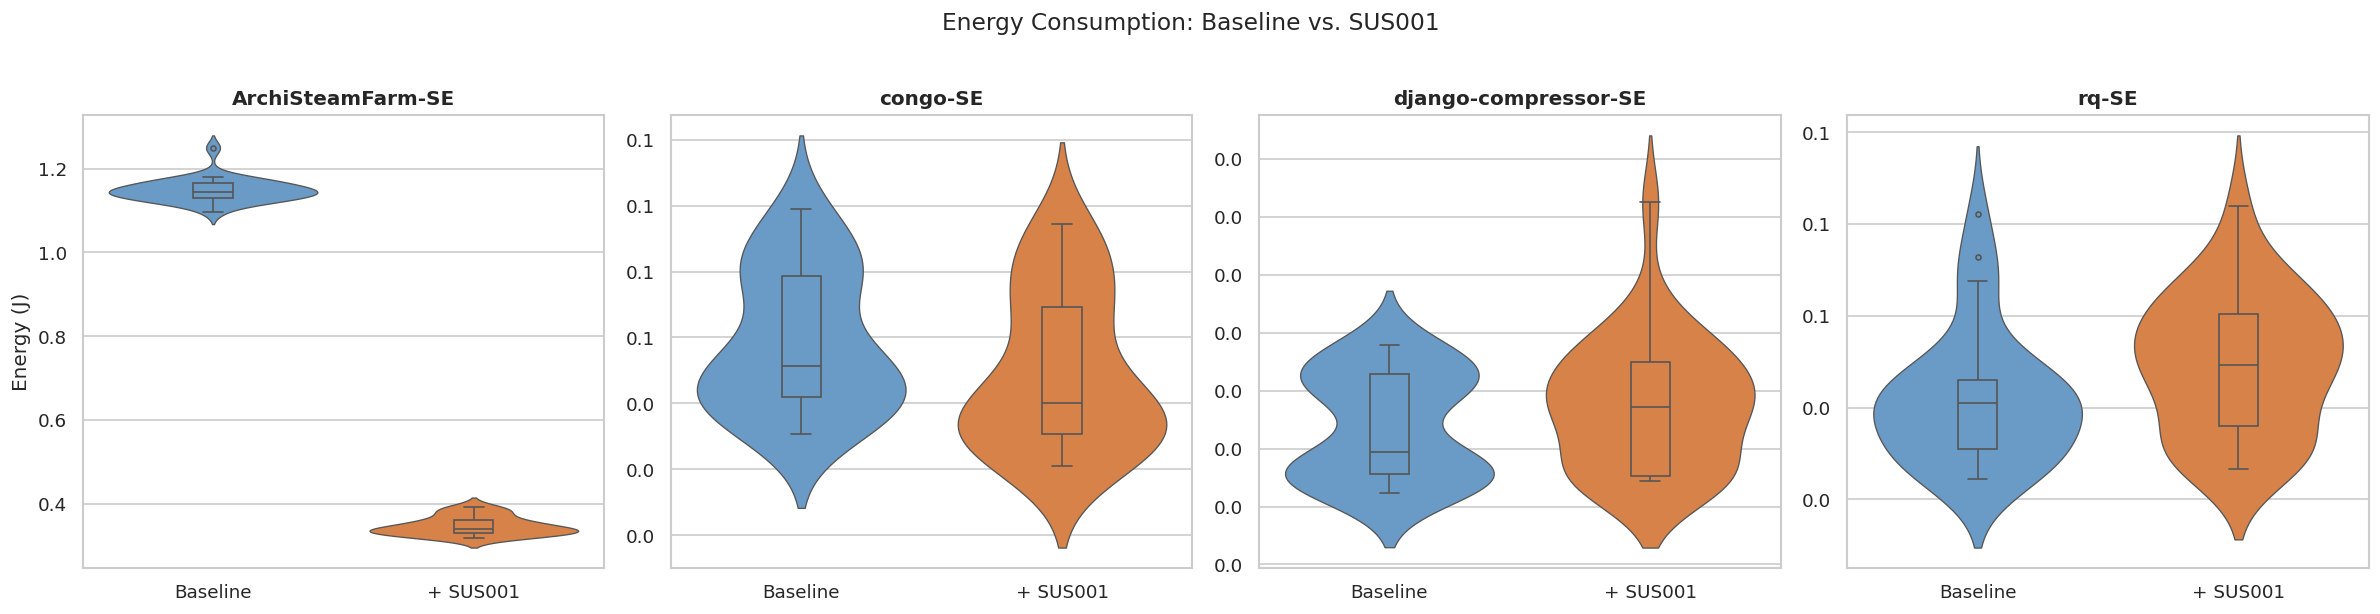

Figure saved to violin_boxplot.png


In [8]:
repos     = sorted(df_wide[REPO_COL].unique())
n_repos   = len(repos)
fig, axes = plt.subplots(1, n_repos, figsize=(5 * n_repos, 5), sharey=False)

if n_repos == 1:
    axes = [axes]

COLORS = ["#5B9BD5", "#ED7D31"]
ORDER  = ["Baseline", "+ SUS001"]

for ax, repo in zip(axes, repos):
    sub = df_wide[df_wide[REPO_COL] == repo]

    melted = sub.melt(
        id_vars=[REPO_COL, RUN_INDEX_COL],
        value_vars=["energy_baseline", "energy_treatment"],
        var_name="condition",
        value_name=ENERGY_COL,
    )
    melted["condition"] = melted["condition"].map({
        "energy_baseline":  "Baseline",
        "energy_treatment": "+ SUS001",
    })

    sns.violinplot(
        data=melted, x="condition", y=ENERGY_COL,
        hue="condition", hue_order=ORDER,
        palette=COLORS, inner=None,
        linewidth=0.8, ax=ax, order=ORDER, legend=False
    )
    sns.boxplot(
        data=melted, x="condition", y=ENERGY_COL,
        hue="condition", hue_order=ORDER,
        width=0.15, palette=COLORS,
        showcaps=True, fliersize=3,
        boxprops=dict(zorder=2), ax=ax,
        order=ORDER, legend=False
    )

    ax.set_title(repo, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Energy (J)" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.1f}"))

fig.suptitle("Energy Consumption: Baseline vs. SUS001", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "violin_boxplot.png"), bbox_inches="tight")
plt.show()
print("Figure saved to violin_boxplot.png")

### 0.8 Visualisation -- Paired Differences per Repository

Histogram of `diff = treatment - baseline` for each repository, with a reference line at 0.

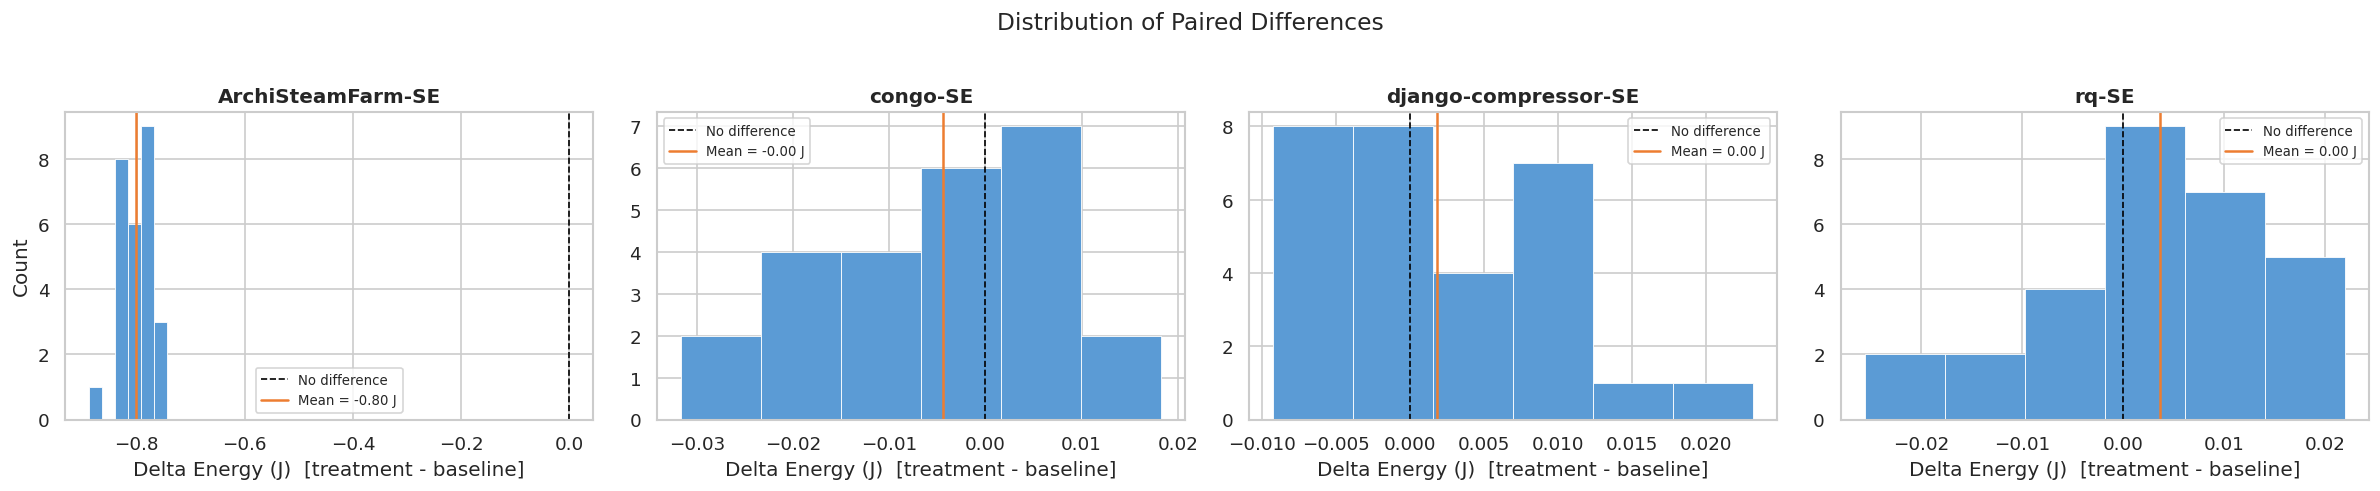

Figure saved to paired_differences.png


In [9]:
fig, axes = plt.subplots(1, n_repos, figsize=(5 * n_repos, 4), sharey=False)
if n_repos == 1:
    axes = [axes]

for ax, repo in zip(axes, repos):
    diffs = df_wide.loc[df_wide[REPO_COL] == repo, "diff"]

    ax.hist(diffs, bins="auto", color="#5B9BD5", edgecolor="white", linewidth=0.5)
    ax.axvline(0,            color="black",   linestyle="--", linewidth=1,   label="No difference")
    ax.axvline(diffs.mean(), color="#ED7D31", linestyle="-",  linewidth=1.5, label=f"Mean = {diffs.mean():.2f} J")

    ax.set_title(repo, fontsize=12, fontweight="bold")
    ax.set_xlabel("Delta Energy (J)  [treatment - baseline]")
    ax.set_ylabel("Count" if ax == axes[0] else "")
    ax.legend(fontsize=8)

fig.suptitle("Distribution of Paired Differences", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "paired_differences.png"), bbox_inches="tight")
plt.show()
print("Figure saved to paired_differences.png")

---
## Stage 1 -- Per-Repository Statistical Tests

For each repository we:
1. Test the paired differences for normality (Shapiro-Wilk)
2. Branch based on the result:
   - **Normal** -> paired t-test, Cohen's d, 95% CI of the mean difference
   - **Non-normal** -> Wilcoxon signed-rank test, rank-biserial correlation, bootstrapped 95% CI of the median difference
3. Inspect Q-Q plots to visualise the distribution shape

### 1.1 Helper Functions

In [10]:
from scipy.stats import shapiro, ttest_rel, wilcoxon
from scipy.stats import t as t_dist

# -- significance threshold (pre-registered) ---------------------------------
ALPHA          = 0.05
N_BOOTSTRAP    = 10_000   # resamples for the bootstrapped CI
BOOTSTRAP_SEED = 42
# ---------------------------------------------------------------------------


def cohens_d_paired(diffs: np.ndarray) -> float:
    """Cohen's d for paired data: mean(diff) / std(diff, ddof=1)."""
    return diffs.mean() / diffs.std(ddof=1)


def ci_mean_parametric(diffs: np.ndarray, alpha: float = 0.05):
    """95% CI for the mean difference using the t-distribution."""
    n      = len(diffs)
    se     = diffs.std(ddof=1) / np.sqrt(n)
    t_c    = t_dist.ppf(1 - alpha / 2, df=n - 1)
    margin = t_c * se
    return diffs.mean() - margin, diffs.mean() + margin


def rank_biserial(diffs: np.ndarray) -> float:
    """
    Rank-biserial correlation for the Wilcoxon signed-rank test.
    Formula: r = 1 - (2 * W) / (n * (n + 1) / 2)
    where W is the test statistic returned by scipy (sum of ranks of the
    smaller-magnitude group). Equivalent to the matched-pairs r_rb.
    """
    n       = len(diffs)
    stat, _ = wilcoxon(diffs, alternative="two-sided")
    max_w   = n * (n + 1) / 2
    return 1 - (2 * stat) / max_w


def ci_median_bootstrap(
    diffs: np.ndarray,
    n_resamples: int = N_BOOTSTRAP,
    alpha: float     = 0.05,
    seed: int        = BOOTSTRAP_SEED,
):
    """Bootstrapped percentile CI for the median difference."""
    rng          = np.random.default_rng(seed)
    boot_medians = [
        np.median(rng.choice(diffs, size=len(diffs), replace=True))
        for _ in range(n_resamples)
    ]
    lo = np.percentile(boot_medians, 100 * alpha / 2)
    hi = np.percentile(boot_medians, 100 * (1 - alpha / 2))
    return lo, hi


print("Helper functions defined.")

Helper functions defined.


### 1.2 Shapiro-Wilk Normality Test

Applied to the paired differences of each repository. If p > 0.05, the differences are treated as approximately normally distributed and the parametric path is used.

In [11]:
normality_results = {}

print(f"Shapiro-Wilk normality test on paired differences  (alpha = {ALPHA})")
print("-" * 60)
print(f"{'Repo':<30} {'W':>8} {'p-value':>10} {'Normal?':>10}")
print("-" * 60)

for repo in repos:
    diffs   = df_wide.loc[df_wide[REPO_COL] == repo, "diff"].to_numpy()
    W, p    = shapiro(diffs)
    is_norm = p > ALPHA
    normality_results[repo] = {"W": W, "p": p, "normal": is_norm, "diffs": diffs}
    flag    = "yes" if is_norm else "no"
    print(f"{repo:<30} {W:>8.4f} {p:>10.4f} {flag:>10}")

print("-" * 60)

Shapiro-Wilk normality test on paired differences  (alpha = 0.05)
------------------------------------------------------------
Repo                                  W    p-value    Normal?
------------------------------------------------------------
ArchiSteamFarm-SE                0.9697     0.5944        yes
congo-SE                         0.9767     0.8126        yes
django-compressor-SE             0.9478     0.1607        yes
rq-SE                            0.9633     0.3948        yes
------------------------------------------------------------


### 1.3 Q-Q Plots

Visual complement to the Shapiro-Wilk test -- points close to the diagonal indicate normality.

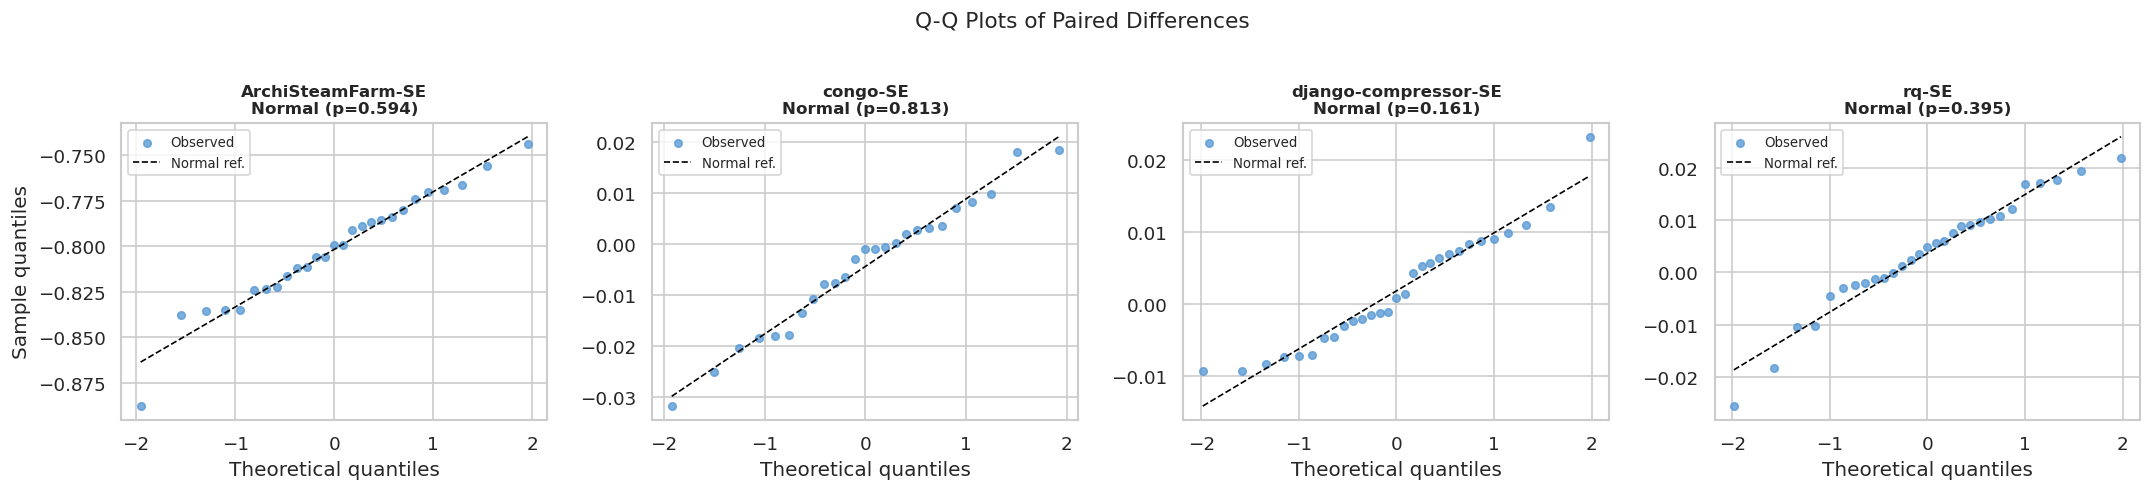

Figure saved to qq_plots.png


In [12]:
from scipy.stats import probplot

fig, axes = plt.subplots(1, n_repos, figsize=(4.5 * n_repos, 4))
if n_repos == 1:
    axes = [axes]

for ax, repo in zip(axes, repos):
    res   = normality_results[repo]
    diffs = res["diffs"]
    color = "#5B9BD5" if res["normal"] else "#ED7D31"

    (osm, osr), (slope, intercept, _) = probplot(diffs, dist="norm")
    ax.scatter(osm, osr, color=color, s=20, alpha=0.8, label="Observed")
    ax.plot(
        [osm.min(), osm.max()],
        [slope * osm.min() + intercept, slope * osm.max() + intercept],
        color="black", linewidth=1, linestyle="--", label="Normal ref."
    )

    norm_str = f"Normal (p={res['p']:.3f})" if res['normal'] else f"Non-normal (p={res['p']:.3f})"
    ax.set_title(f"{repo}\n{norm_str}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Sample quantiles" if ax == axes[0] else "")
    ax.legend(fontsize=8)

fig.suptitle("Q-Q Plots of Paired Differences", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "qq_plots.png"), bbox_inches="tight")
plt.show()
print("Figure saved to qq_plots.png")

### 1.4 Per-Repository Statistical Tests

Each repository is tested with the method selected by the Shapiro-Wilk result above:

| Normal? | Test | Effect size | CI |
|---------|------|-------------|----|
| Yes | Paired t-test | Cohen's d | Parametric (t-distribution) |
| No  | Wilcoxon signed-rank | Rank-biserial r | Bootstrapped percentile |

In [13]:
per_repo_results = []

for repo in repos:
    res   = normality_results[repo]
    diffs = res["diffs"]
    n     = len(diffs)
    row   = {
        "repo":        repo,
        "n":           n,
        "mean_diff":   diffs.mean(),
        "median_diff": np.median(diffs),
        "std_diff":    diffs.std(ddof=1),
        "sw_p":        res["p"],
        "normal":      res["normal"],
    }

    if res["normal"]:
        # Parametric path
        t_stat, p_val = ttest_rel(diffs, np.zeros(n))
        d             = cohens_d_paired(diffs)
        ci_lo, ci_hi  = ci_mean_parametric(diffs, ALPHA)
        row.update({
            "test":         "paired t-test",
            "stat":         t_stat,
            "p_value":      p_val,
            "effect_size":  d,
            "effect_label": "Cohen's d",
            "ci_lo":        ci_lo,
            "ci_hi":        ci_hi,
            "ci_on":        "mean diff",
        })
    else:
        # Non-parametric path
        w_stat, p_val = wilcoxon(diffs, alternative="two-sided")
        r_rb          = rank_biserial(diffs)
        ci_lo, ci_hi  = ci_median_bootstrap(diffs)
        row.update({
            "test":         "Wilcoxon signed-rank",
            "stat":         w_stat,
            "p_value":      p_val,
            "effect_size":  r_rb,
            "effect_label": "rank-biserial r",
            "ci_lo":        ci_lo,
            "ci_hi":        ci_hi,
            "ci_on":        "median diff",
        })

    per_repo_results.append(row)

df_results = pd.DataFrame(per_repo_results)
print("Per-repository test results computed.")

Per-repository test results computed.


### 1.5 Results Table

In [14]:
display_cols = [
    "repo", "n", "mean_diff", "std_diff", "test",
    "stat", "p_value", "effect_size", "effect_label",
    "ci_lo", "ci_hi", "ci_on",
]

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns",  20)
pd.set_option("display.width",        120)

df_display = df_results[display_cols].copy()
df_display["significant"] = df_results["p_value"].apply(
    lambda p: f"yes (p={p:.4f})" if p <= ALPHA else f"no  (p={p:.4f})"
)
df_display

,repo,n,mean_diff,std_diff,test,stat,p_value,effect_size,effect_label,ci_lo,ci_hi,ci_on,significant
0,ArchiSteamFarm-SE,27,-0.8017,0.0310,paired t-test,-134.2026,0.0000,-25.8273,Cohen's d,-0.8140,-0.7894,mean diff,yes (p=0.0000)
1,congo-SE,25,-0.0044,0.0128,paired t-test,-1.7301,0.0965,-0.3460,Cohen's d,-0.0097,0.0009,mean diff,no (p=0.0965)
2,django-compressor-SE,29,0.0018,0.0079,paired t-test,1.2307,0.2287,0.2285,Cohen's d,-0.0012,0.0048,mean diff,no (p=0.2287)
3,rq-SE,29,0.0037,0.0110,paired t-test,1.7857,0.0850,0.3316,Cohen's d,-0.0005,0.0079,mean diff,no (p=0.0850)


### 1.6 Verbose Per-Repository Summary

In [15]:
def interpret_effect(label: str, value: float) -> str:
    """Verbal label for effect magnitude."""
    abs_v = abs(value)
    if label == "Cohen's d":
        if abs_v < 0.2: return "negligible"
        if abs_v < 0.5: return "small"
        if abs_v < 0.8: return "medium"
        return "large"
    else:  # rank-biserial
        if abs_v < 0.1: return "negligible"
        if abs_v < 0.3: return "small"
        if abs_v < 0.5: return "medium"
        return "large"

for _, row in df_results.iterrows():
    sig    = row["p_value"] <= ALPHA
    effect = interpret_effect(row["effect_label"], row["effect_size"])

    print("-" * 60)
    print(f"  Repository : {row['repo']}")
    print(f"  n pairs    : {int(row['n'])}")
    print(f"  Method     : {row['test']} ({'normal' if row['normal'] else 'non-normal'} diffs)")
    print(f"  Mean diff  : {row['mean_diff']:+.4f} J  (treatment - baseline)")
    print(f"  Std diff   : {row['std_diff']:.4f} J")
    print(f"  Test stat  : {row['stat']:.4f}    p = {row['p_value']:.4f}")
    print(f"  Significant: {'yes' if sig else 'no'}  (alpha = {ALPHA})")
    print(f"  {row['effect_label']:17s}: {row['effect_size']:+.4f}  ({effect} effect)")
    print(f"  95% CI ({row['ci_on']}): [{row['ci_lo']:+.4f},  {row['ci_hi']:+.4f}]")
    print()
print("-" * 60)

------------------------------------------------------------
  Repository : ArchiSteamFarm-SE
  n pairs    : 27
  Method     : paired t-test (normal diffs)
  Mean diff  : -0.8017 J  (treatment - baseline)
  Std diff   : 0.0310 J
  Test stat  : -134.2026    p = 0.0000
  Significant: yes  (alpha = 0.05)
  Cohen's d        : -25.8273  (large effect)
  95% CI (mean diff): [-0.8140,  -0.7894]

------------------------------------------------------------
  Repository : congo-SE
  n pairs    : 25
  Method     : paired t-test (normal diffs)
  Mean diff  : -0.0044 J  (treatment - baseline)
  Std diff   : 0.0128 J
  Test stat  : -1.7301    p = 0.0965
  Significant: no  (alpha = 0.05)
  Cohen's d        : -0.3460  (small effect)
  95% CI (mean diff): [-0.0097,  +0.0009]

------------------------------------------------------------
  Repository : django-compressor-SE
  n pairs    : 29
  Method     : paired t-test (normal diffs)
  Mean diff  : +0.0018 J  (treatment - baseline)
  Std diff   : 0.0079

---
## Stage 2 -- Linear Mixed-Effects Model

We fit a single model on the raw trial-level data across all repositories:

$$\text{energy}_{ij} = \beta_0 + \beta_1 \cdot \text{sus001}_{ij} + u_j + \varepsilon_{ij}$$

- $\beta_1$ -- fixed effect of SUS001 (the overall mean difference)
- $u_j \sim \mathcal{N}(0, \sigma^2_u)$ -- random intercept per repository
- $\varepsilon_{ij} \sim \mathcal{N}(0, \sigma^2)$ -- residual error

The model is fitted on **raw energy values** (not paired differences), so it uses all trial-level variance directly.

### 2.1 Prepare Model Data

In [16]:
import statsmodels.formula.api as smf

# Keep only clean paired runs (same run_indices retained in df_wide)
valid_index = df_wide.set_index([REPO_COL, RUN_INDEX_COL]).index
df_model = df_raw[
    df_raw.set_index([REPO_COL, RUN_INDEX_COL]).index.isin(valid_index)
].copy()

# Binary fixed-effect: 1 = SUS001 applied, 0 = baseline
df_model["sus001"] = (df_model[CONDITION_COL] == TREATMENT_LABEL).astype(int)

print(f"Model dataset: {len(df_model):,} rows across {df_model[REPO_COL].nunique()} repositories")
print("Condition encoding: baseline -> 0,  treatment -> 1")
df_model[[REPO_COL, CONDITION_COL, "sus001", ENERGY_COL]].head(8)

Model dataset: 220 rows across 4 repositories
Condition encoding: baseline -> 0,  treatment -> 1


,repo,condition,sus001,total_energy_j
0,ArchiSteamFarm-SE,baseline,0,1.1180
1,ArchiSteamFarm-SE,treatment,1,0.3381
2,ArchiSteamFarm-SE,baseline,0,1.1648
3,ArchiSteamFarm-SE,treatment,1,0.3908
4,ArchiSteamFarm-SE,baseline,0,1.1426
5,ArchiSteamFarm-SE,treatment,1,0.3365
6,ArchiSteamFarm-SE,baseline,0,1.1489
7,ArchiSteamFarm-SE,treatment,1,0.3493


### 2.2 Fit the Mixed-Effects Model

In [17]:
formula = f"{ENERGY_COL} ~ sus001"

lme_model  = smf.mixedlm(formula, data=df_model, groups=df_model[REPO_COL])
lme_result = lme_model.fit(reml=True)   # REML gives unbiased variance estimates

print(lme_result.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: total_energy_j
No. Observations: 220     Method:             REML          
No. Groups:       4       Scale:              0.0307        
Min. group size:  50      Log-Likelihood:     57.5158       
Max. group size:  58      Converged:          Yes           
Mean group size:  55.0                                      
-------------------------------------------------------------
              Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept      0.312     0.178   1.749  0.080  -0.038   0.662
sus001        -0.196     0.024  -8.310  0.000  -0.243  -0.150
Group Var      0.126     0.595                               



### 2.3 Extract Key Estimates

In [18]:
# Fixed effect for SUS001
beta1       = lme_result.params["sus001"]
p_fixed     = lme_result.pvalues["sus001"]
ci_fixed    = lme_result.conf_int().loc["sus001"]
ci_lo_fixed = ci_fixed[0]
ci_hi_fixed = ci_fixed[1]

# Random effect variance (between-repository variability)
re_var  = float(lme_result.cov_re.iloc[0, 0])
re_std  = np.sqrt(re_var)

# Residual variance
resid_var = lme_result.scale

print("Mixed-Effects Model -- Key Estimates")
print("-" * 55)
print(f"  Overall mean difference (beta1) : {beta1:+.4f} J")
print(f"  95% CI                          : [{ci_lo_fixed:+.4f},  {ci_hi_fixed:+.4f}]")
print(f"  p-value (fixed effect)           : {p_fixed:.4f}  ({'significant' if p_fixed <= ALPHA else 'not significant'})")
print()
print(f"  Random-effect std  (sigma_u)    : {re_std:.4f} J  (between-repo SD)")
print(f"  Random-effect var  (sigma2_u)   : {re_var:.4f} J^2")
print(f"  Residual std       (sigma)      : {np.sqrt(resid_var):.4f} J")
print("-" * 55)

Mixed-Effects Model -- Key Estimates
-------------------------------------------------------
  Overall mean difference (beta1) : -0.1963 J
  95% CI                          : [-0.2427,  -0.1500]
  p-value (fixed effect)           : 0.0000  (significant)

  Random-effect std  (sigma_u)    : 0.3554 J  (between-repo SD)
  Random-effect var  (sigma2_u)   : 0.1263 J^2
  Residual std       (sigma)      : 0.1752 J
-------------------------------------------------------


### 2.4 Per-Repository Random Effect Deviations

Each repository's estimated deviation from the overall intercept, independent of SUS001.

In [19]:
# random_effects is a dict of {repo: Series}; convert to DataFrame directly
re_df = (
    pd.DataFrame(lme_result.random_effects)
    .T                                     # repos as rows
    .iloc[:, 0]                            # first (and only) column = random intercept
    .rename("re_deviation")
    .reset_index()
    .rename(columns={"index": REPO_COL})
)

re_df["intercept_estimate"] = lme_result.params["Intercept"] + re_df["re_deviation"]
re_df = re_df.sort_values("re_deviation", ascending=False).reset_index(drop=True)

pd.set_option("display.float_format", "{:.4f}".format)
print("Per-repository random intercept deviations:")
re_df

Per-repository random intercept deviations:


,repo,re_deviation,intercept_estimate
0,ArchiSteamFarm-SE,0.5317,0.8438
1,congo-SE,-0.1661,0.1460
2,rq-SE,-0.1704,0.1417
3,django-compressor-SE,-0.1952,0.1169


### 2.5 Figure -- Effect Plot

The overall estimated effect of SUS001 with its 95% confidence interval.

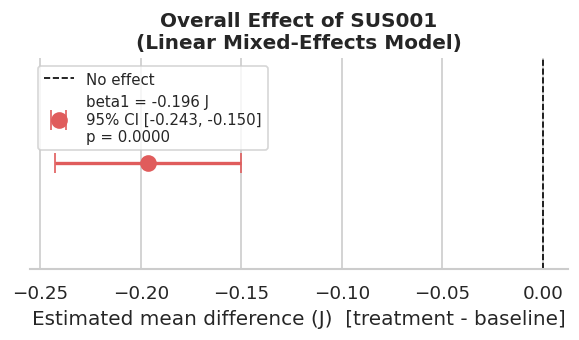

Figure saved to effect_plot.png


In [20]:
fig, ax = plt.subplots(figsize=(5, 3))

color = "#E05C5C" if p_fixed <= ALPHA else "#5B9BD5"

ax.errorbar(
    x=[beta1], y=[0],
    xerr=[[beta1 - ci_lo_fixed], [ci_hi_fixed - beta1]],
    fmt="o", color=color, markersize=9, capsize=6, linewidth=2,
    label=f"beta1 = {beta1:+.3f} J\n95% CI [{ci_lo_fixed:+.3f}, {ci_hi_fixed:+.3f}]\np = {p_fixed:.4f}"
)
ax.axvline(0, color="black", linestyle="--", linewidth=1, label="No effect")

ax.set_yticks([])
ax.set_xlabel("Estimated mean difference (J)  [treatment - baseline]")
ax.set_title("Overall Effect of SUS001\n(Linear Mixed-Effects Model)", fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
sns.despine(left=True)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "effect_plot.png"), bbox_inches="tight")
plt.show()
print("Figure saved to effect_plot.png")

### 2.6 Figure -- Forest Plot

Per-repository mean differences (from Stage 1) alongside the combined mixed-effects estimate.

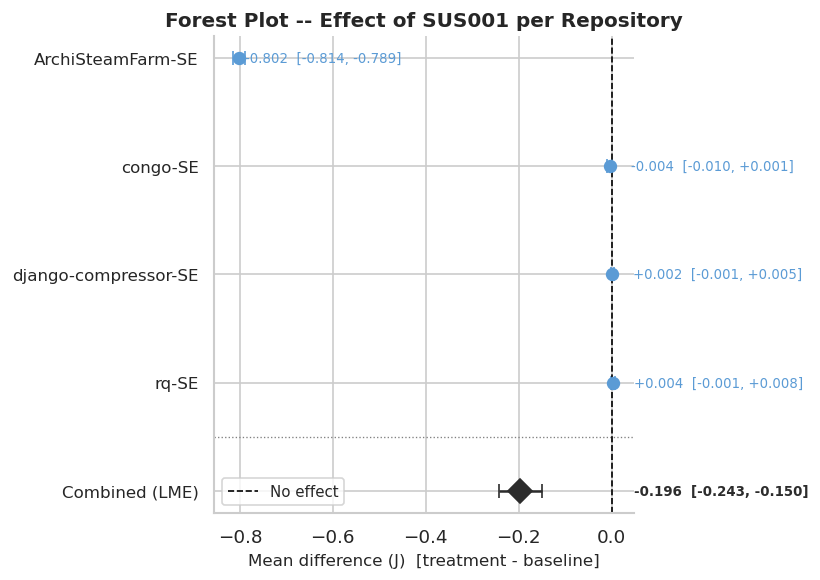

Figure saved to forest_plot.png


In [21]:
forest_rows = []
for _, row in df_results.iterrows():
    forest_rows.append({
        "label":       row["repo"],
        "estimate":    row["mean_diff"],
        "ci_lo":       row["ci_lo"],
        "ci_hi":       row["ci_hi"],
        "is_combined": False,
    })

forest_rows.append({
    "label":       "Combined (LME)",
    "estimate":    beta1,
    "ci_lo":       ci_lo_fixed,
    "ci_hi":       ci_hi_fixed,
    "is_combined": True,
})

forest_df = pd.DataFrame(forest_rows)

n_rows = len(forest_df)
y_pos  = list(range(n_rows - 1, -1, -1))

fig, ax = plt.subplots(figsize=(7, 0.7 * n_rows + 1.5))

for i, (_, row) in enumerate(forest_df.iterrows()):
    y       = y_pos[i]
    is_comb = row["is_combined"]
    color   = "#2C2C2C" if is_comb else "#5B9BD5"
    marker  = "D" if is_comb else "o"
    size    = 10 if is_comb else 7

    ax.errorbar(
        x=row["estimate"], y=y,
        xerr=[[row["estimate"] - row["ci_lo"]], [row["ci_hi"] - row["estimate"]]],
        fmt=marker, color=color, markersize=size,
        capsize=4, linewidth=1.5 if is_comb else 1,
    )

    ax.text(
        ax.get_xlim()[1] if ax.get_xlim()[1] != 0 else 1,
        y,
        f"{row['estimate']:+.3f}  [{row['ci_lo']:+.3f}, {row['ci_hi']:+.3f}]",
        va="center", ha="left", fontsize=8,
        color=color, fontweight="bold" if is_comb else "normal",
    )

ax.axhline(0.5, color="grey", linewidth=0.8, linestyle=":")
ax.axvline(0,   color="black", linewidth=1,  linestyle="--", label="No effect")

ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df["label"], fontsize=10)
ax.set_xlabel("Mean difference (J)  [treatment - baseline]", fontsize=10)
ax.set_title("Forest Plot -- Effect of SUS001 per Repository", fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "forest_plot.png"), bbox_inches="tight")
plt.show()
print("Figure saved to forest_plot.png")

### 2.7 Final Summary Table

Combines per-repository results from Stage 1 with the mixed-effects model output.

In [22]:
summary_per_repo = df_results[[
    "repo", "n", "mean_diff", "std_diff",
    "test", "p_value", "effect_label", "effect_size",
    "ci_lo", "ci_hi", "ci_on",
]].copy()
summary_per_repo["significant"] = summary_per_repo["p_value"] <= ALPHA
summary_per_repo = summary_per_repo.rename(columns={
    "mean_diff": "mean_diff_J",
    "std_diff":  "std_diff_J",
    "ci_lo":     "ci_lo_J",
    "ci_hi":     "ci_hi_J",
})

print("Per-repository results:")
pd.set_option("display.float_format", "{:.4f}".format)
display(summary_per_repo)

summary_lme = pd.DataFrame([{
    "estimate_J":     beta1,
    "ci_lo_J":        ci_lo_fixed,
    "ci_hi_J":        ci_hi_fixed,
    "p_value":        p_fixed,
    "significant":    p_fixed <= ALPHA,
    "re_variance_J2": re_var,
    "re_std_J":       re_std,
    "residual_std_J": np.sqrt(resid_var),
}])

print("\nCombined mixed-effects model estimate:")
display(summary_lme)

Per-repository results:


,repo,n,mean_diff_J,std_diff_J,test,p_value,effect_label,effect_size,ci_lo_J,ci_hi_J,ci_on,significant
0,ArchiSteamFarm-SE,27,-0.8017,0.0310,paired t-test,0.0000,Cohen's d,-25.8273,-0.8140,-0.7894,mean diff,True
1,congo-SE,25,-0.0044,0.0128,paired t-test,0.0965,Cohen's d,-0.3460,-0.0097,0.0009,mean diff,False
2,django-compressor-SE,29,0.0018,0.0079,paired t-test,0.2287,Cohen's d,0.2285,-0.0012,0.0048,mean diff,False
3,rq-SE,29,0.0037,0.0110,paired t-test,0.0850,Cohen's d,0.3316,-0.0005,0.0079,mean diff,False



Combined mixed-effects model estimate:


,estimate_J,ci_lo_J,ci_hi_J,p_value,significant,re_variance_J2,re_std_J,residual_std_J
0,-0.1963,-0.2427,-0.1500,0.0000,True,0.1263,0.3554,0.1752


### 2.8 Export Results to CSV

In [23]:

summary_per_repo.to_csv(os.path.join(RESULTS_DIR, "results_per_repo.csv"), index=False)
summary_lme.to_csv(os.path.join(RESULTS_DIR, "results_lme.csv"), index=False)
print("Saved: results_per_repo.csv")
print("Saved: results_lme.csv")

Saved: results_per_repo.csv
Saved: results_lme.csv
